In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
# Create a 5x5 array with random integers between 1 and 50
arr = np.random.randint(1, 51, size=(5, 5))
print("Original Array:\n", arr)

# Find row with maximum sum
row_sums = arr.sum(axis=1)
max_row_index = np.argmax(row_sums)
print("\nRow with maximum sum:", arr[max_row_index])
print("Maximum sum:", row_sums[max_row_index])

# Replace elements greater than mean with 0
mean_val = arr.mean()
arr_modified = np.where(arr > mean_val, 0, arr)
print("\nArray after replacing values > mean with 0:\n", arr_modified)

Original Array:
 [[42 47 39 12 26]
 [44  2 30  4 39]
 [49 49 24 21 47]
 [30 25  2  3 11]
 [ 1 16  6 26 40]]

Row with maximum sum: [49 49 24 21 47]
Maximum sum: 190

Array after replacing values > mean with 0:
 [[ 0  0  0 12  0]
 [ 0  2  0  4  0]
 [ 0  0 24 21  0]
 [ 0 25  2  3 11]
 [ 1 16  6  0  0]]


In [3]:
# Create array from 1 to 20
arr2 = np.arange(1, 21)
print("\nOriginal Array:", arr2)

# Select every 3rd element starting from the 2nd element
selected = arr2[1::3]
print("Selected Elements:", selected)


Original Array: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Selected Elements: [ 2  5  8 11 14 17 20]


In [4]:
# Load dataset
iris = load_iris(as_frame=True)
df = iris.frame

# Rename columns
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# Display first 10 rows
print("First 10 rows:\n", df.head(10))

# Basic statistics
print("\nBasic Statistics:\n", df.describe())

First 10 rows:
    sepal_length  sepal_width  petal_length  petal_width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0
5           5.4          3.9           1.7          0.4        0
6           4.6          3.4           1.4          0.3        0
7           5.0          3.4           1.5          0.2        0
8           4.4          2.9           1.4          0.2        0
9           4.9          3.1           1.5          0.1        0

Basic Statistics:
        sepal_length  sepal_width  petal_length  petal_width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866 

In [5]:
# Median of sepal_length
median_val = df['sepal_length'].median()

# Filter condition
filtered_df = df[(df['sepal_length'] > median_val) & (df['species'] == 1)]
print("\nFiltered Data:\n", filtered_df)


Filtered Data:
     sepal_length  sepal_width  petal_length  petal_width  species
50           7.0          3.2           4.7          1.4        1
51           6.4          3.2           4.5          1.5        1
52           6.9          3.1           4.9          1.5        1
54           6.5          2.8           4.6          1.5        1
56           6.3          3.3           4.7          1.6        1
58           6.6          2.9           4.6          1.3        1
61           5.9          3.0           4.2          1.5        1
62           6.0          2.2           4.0          1.0        1
63           6.1          2.9           4.7          1.4        1
65           6.7          3.1           4.4          1.4        1
68           6.2          2.2           4.5          1.5        1
70           5.9          3.2           4.8          1.8        1
71           6.1          2.8           4.0          1.3        1
72           6.3          2.5           4.9          1.5   

In [6]:
grouped = df.groupby('species')['petal_length'].mean()
print("\nMean petal_length by species:\n", grouped)


Mean petal_length by species:
 species
0    1.462
1    4.260
2    5.552
Name: petal_length, dtype: float64


In [7]:
# Add petal_ratio column
df['petal_ratio'] = df['petal_length'] / df['petal_width']

# Top 5 rows
top5 = df.sort_values(by='petal_ratio', ascending=False).head(5)
print("\nTop 5 rows with highest petal_ratio:\n", top5)


Top 5 rows with highest petal_ratio:
     sepal_length  sepal_width  petal_length  petal_width  species  petal_ratio
9            4.9          3.1           1.5          0.1        0         15.0
32           5.2          4.1           1.5          0.1        0         15.0
37           4.9          3.6           1.4          0.1        0         14.0
12           4.8          3.0           1.4          0.1        0         14.0
13           4.3          3.0           1.1          0.1        0         11.0


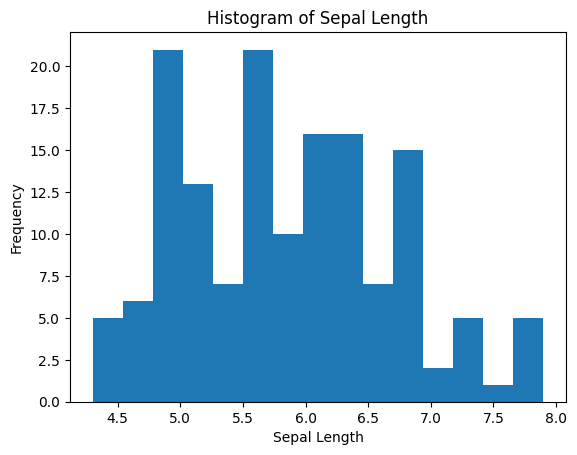

In [8]:
plt.figure()
plt.hist(df['sepal_length'], bins=15)
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

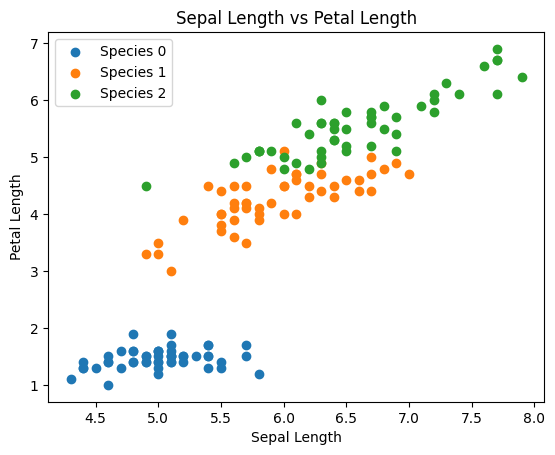

In [9]:
plt.figure()

for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal_length'], subset['petal_length'], label=f"Species {species}")

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.legend()
plt.show()

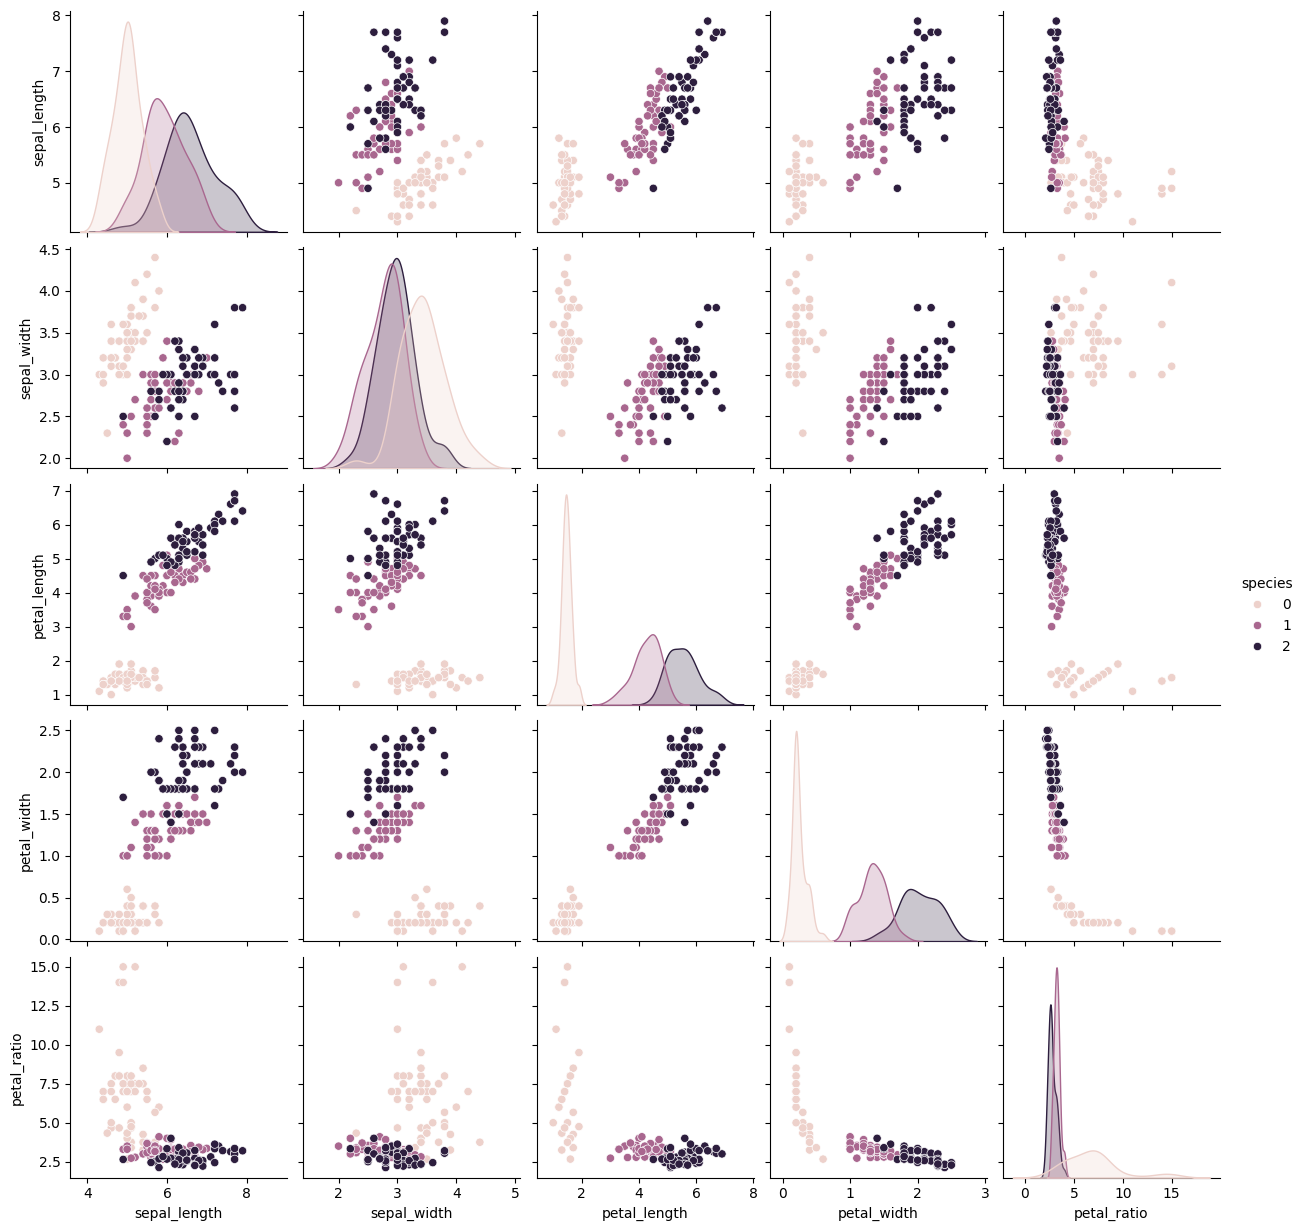

In [10]:
sns.pairplot(df, hue='species')
plt.show()

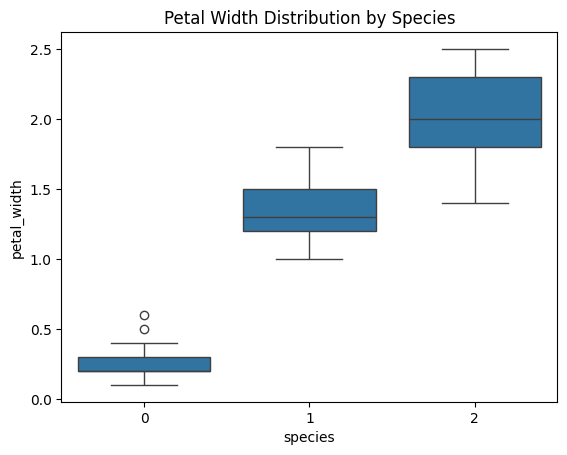

In [11]:
plt.figure()
sns.boxplot(x='species', y='petal_width', data=df)
plt.title("Petal Width Distribution by Species")
plt.show()